In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from local_utils import detect_lp
from os.path import splitext, basename
from keras.models import model_from_json
import glob

%matplotlib inline


Wpod-net.h: saved weights of our trained network
Wpod-net.json: model architecture

In [2]:
def load_model(path):
    try:
        path = splitext(path)[0]
        with open('%s.json' % path, 'r') as json_file:
            model_json = json_file.read()
        model = model_from_json(model_json, custom_objects={})
        model.load_weights('%s.h5' % path)
        print("Loading model successfully...")
        return model
    except Exception as e:
        print(e)

wpod_net_path = "wpod-net.json"
wpod_net = load_model(wpod_net_path)

Loading model successfully...


This function basicyally reads the parsing image, converts it to RGB, and normalizes the image data to 0–1 range. so it can be compatible with matplotlib. Additionally, we can set resize = True to resize all images to same dimension of (width = 224, height = 224) for visualizing purpose in the next step.

In [3]:
def preprocess_image(image_path,resize=False):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255
    if resize:
        img = cv2.resize(img, (224,224))
    return img


This dataset contains of 20 vehicle images with plate acquired from 10 different countries (Germany, Vietnam, Japan, Thailand, Saudi, Russia, Korea, Usa, India, China). The following block of code will display our plate images and their country names in a figure containing of 5 columns and 4 rows

Found 18 images...


/usr/local/anaconda3/envs/plates/lib/python3.7/site-packages/ipykernel_launcher.py:19: MatplotlibDeprecationWarning: Passing the pad parameter of tight_layout() positionally is deprecated since Matplotlib 3.3; the parameter will become keyword-only two minor releases later.


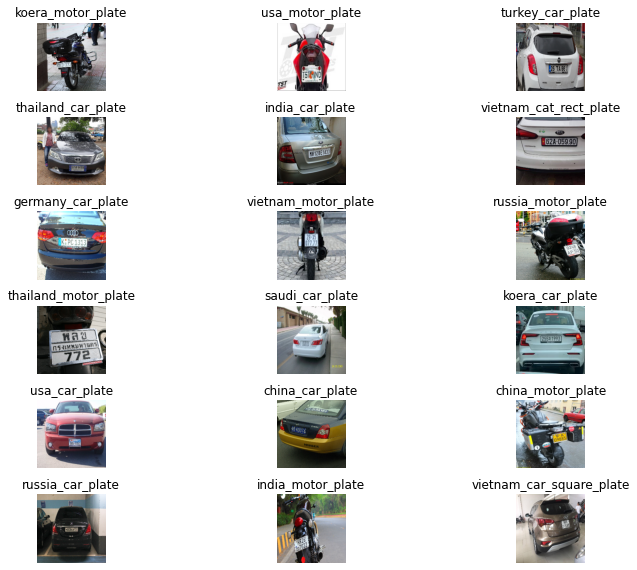

In [4]:
# Create a list of image paths 
image_paths = glob.glob("Plate_examples/*.jpg")
print("Found %i images..."%(len(image_paths)))

# Visualize data in subplot 
fig = plt.figure(figsize=(12,8))
cols = 3
rows = 6
fig_list = []

for i in range(cols*rows):
    fig_list.append(fig.add_subplot(rows,cols,i+1))
    title = splitext(basename(image_paths[i]))[0]
    fig_list[-1].set_title(title)
    img = preprocess_image(image_paths[i],True)
    plt.axis(False)
    plt.imshow(img)

plt.tight_layout(True)
plt.show()

get_plate function which processes the raw image, send it to our model and return the plate image (LpImg) and its coordinates (cor). If there is no plate founded, the program would warn you with an error “No License plate is founded!”. In this case, try to increase Dmin value to adjust the boundary dimension. It should be mentioned that Wpod-Net is able to detect only standard plates(black character, white background), and if the image is too blurry or the plate is hidden by obstacles, the model might fail to predict it

In [5]:
def get_plate(image_path, Dmax=608, Dmin=256):
    vehicle = preprocess_image(image_path)
    ratio = float(max(vehicle.shape[:2])) / min(vehicle.shape[:2])
    side = int(ratio * Dmin)
    bound_dim = min(side, Dmax)
    _, LpImg, _, cor = detect_lp(wpod_net, vehicle, bound_dim, lp_threshold=0.5)
    return LpImg, cor

In [6]:
# Obtain plate image and its coordinates from an image
test_image = image_paths[0]
LpImg,cor = get_plate(test_image)
print("Detect %i plate(s) in"%len(LpImg),splitext(basename(test_image))[0])
print("Coordinate of plate(s) in image: \n", cor)


Detect 1 plate(s) in koera_motor_plate
Coordinate of plate(s) in image: 
 [array([[148.92242547, 270.39682747, 276.79637337, 155.32197138],
       [404.2325181 , 395.13788413, 439.24858859, 448.34322256],
       [  1.        ,   1.        ,   1.        ,   1.        ]])]


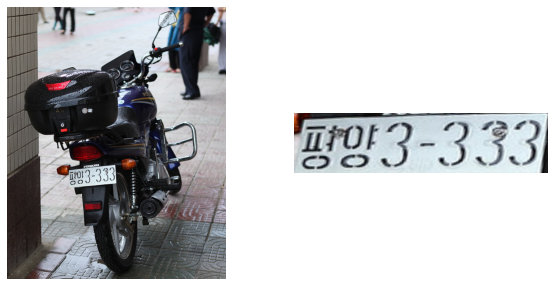

In [7]:

# Visualize our result
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.axis(False)
plt.imshow(preprocess_image(test_image))
plt.subplot(1,2,2)
plt.axis(False)
plt.imshow(LpImg[0])


draw a bounding box with obtained coordinates of detected plate as shown aboved.

In [8]:
def draw_box(image_path, cor, thickness=3):
    pts=[]
    x_coordinates=cor[0][0]
    y_coordinates=cor[0][1]
    # store the top-left, top-right, bottom-left, bottom-right 
    # of the plate license respectively
    for i in range(4):
        pts.append([int(x_coordinates[i]), int(y_coordinates[i])])
        
    pts = np.array(pts, np.int32)
    pts = pts.reshape((-1,1,2))
    vehicle_image = preprocess_image(image_path)
    
    cv2.polylines(vehicle_image,[pts],True,(0,255,0),thickness)
    return vehicle_image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


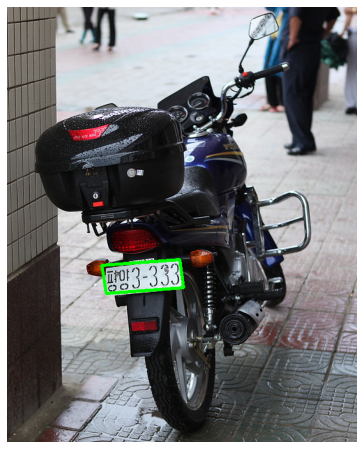

In [9]:
plt.figure(figsize=(8,8))
plt.axis(False)
plt.imshow(draw_box(test_image,cor))

perform get_plate function to all vehicle images and plot the returned plate images.

AssertionError: No License plate is founded!

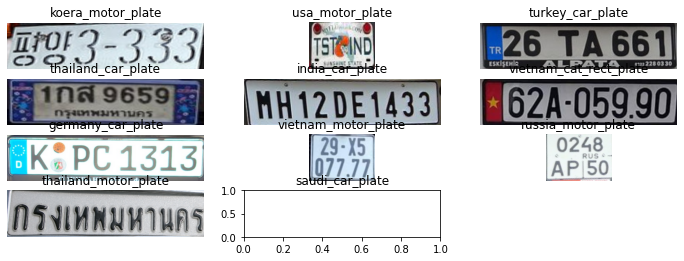

In [10]:
# Viualize all obtained plate images 
fig = plt.figure(figsize=(12,6))
cols = 3
rows = 6
fig_list = []

for i in range(cols*rows):
    fig_list.append(fig.add_subplot(rows, cols, i+1))
    title = splitext(basename(image_paths[i]))[0]
    fig_list[-1].set_title(title)
    LpImg, _ = get_plate(image_paths[i])
    plt.axis(False)
    plt.imshow(LpImg[0])
    
plt.tight_layout(True)
plt.show()

detect multiple license plates in one frame using wpod-Net.

Detect 2 plate(s) in multiple_plates


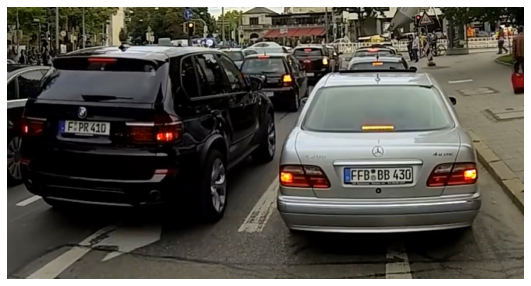

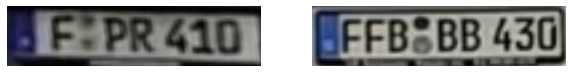

In [11]:
multiple_plates_image = "Plate_examples/multiple_plates.png"
LpImg,cor = get_plate(multiple_plates_image)

print("Detect %i plate(s) in"%len(LpImg),splitext(basename(multiple_plates_image))[0])

# Visualize the original image
plt.figure(figsize=(10,5))
plt.axis(False)
plt.imshow(preprocess_image(multiple_plates_image))

# Visualize the obtained plates
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.axis(False)
plt.imshow(LpImg[1])
plt.subplot(1,2,2)
plt.axis(False)
plt.imshow(LpImg[0])